# Теория вероятностей и математическая статистика

*Алла Тамбовцева*

## Практикум 1. Сравнение двух групп

Импортируем необходимые библиотеки и функции:

In [1]:
import pandas as pd
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

/opt/anaconda3/lib/python3.7/site-packages/statsmodels/tools/_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


### Задача 1: сравнение долей

В файле `SmokeBan.csv` хранятся данные о сотрудниках разных компаний (случайная выборка из [файла](https://www.kaggle.com/datasets/utkarshx27/do-workplace-smoking-bans-reduce-smoking) с Kaggle):

* `smoker`: курит человек или нет;
* `ban`: есть ли запрет на курение на работе;
* `age`: возраст; 
* `education`: образование;
* `gender`: пол.

Проверьте на 10% уровне значимости, можно ли считать, что доли курильщиков среди работающих в местах с запретом на курение и в местах без такого запрета одинаковы.

a. Вычислите количество и долю курильщиков, работающих в местах с запретом на курение, а также число и долю курильщиков, работающих в местах без такого запрета.

b. Сформулируйте нулевую и альтернативную гипотезы. Тип альтернативы (правосторонняя или левосторонняя) выберите, исходя из сравнения долей, полученных в предыдущем пункте. Напишите и запустите необходимый код для проверки гипотезы. Сделайте статистический и содержательный вывод.

In [2]:
url = "https://raw.githubusercontent.com/allatambov/StatCS26/refs/heads/main/SmokeBan.csv"
smoke = pd.read_csv(url).dropna()
smoke.head()

,smoker,ban,age,education,gender
0,yes,yes,18,hs drop out,female
1,no,no,35,some college,female
2,yes,no,34,hs,male
3,no,no,35,some college,female
4,yes,yes,20,hs,female


### Решения

a. Сохраним в датафреймы `ban` и `no_ban` строки, соответствующие сотрудникам, работающим в местах с запретом и без запрета на курение:

In [3]:
ban = smoke[smoke["ban"] == "yes"]
no_ban = smoke[smoke["ban"] == "no"]

In [4]:
ban.head()

,smoker,ban,age,education,gender
0,yes,yes,18,hs drop out,female
4,yes,yes,20,hs,female
5,no,yes,46,master,male
6,no,yes,35,hs,male
8,no,yes,43,master,female


In [5]:
no_ban.head()

,smoker,ban,age,education,gender
1,no,no,35,some college,female
2,yes,no,34,hs,male
3,no,no,35,some college,female
7,no,no,33,some college,male
9,yes,no,64,some college,female


Чтобы не выполнять еще одну фильтрацию для вычисления числа курильщиков в обеих таблицах, проверим условие равенства значений в столбце `smoker` строке `"yes"`, а затем посчитаем по полученному логическому столбцу из `True` и `False`:

* сумму – она равна количеству `True` (`True` и `False` эквивалентны 1 и 0);
* среднее – оно равно доле `True` (доля по бинарному массиву равна среднему по нему же).

In [6]:
smoker_ban = (ban["smoker"] == "yes").sum()
p_smoker_ban = (ban["smoker"] == "yes").mean()

smoker_noban = (no_ban["smoker"] == "yes").sum()
p_smoker_noban = (no_ban["smoker"] == "yes").mean()

print("Запрет есть:", smoker_ban, p_smoker_ban)
print("Запрета нет:", smoker_noban, p_smoker_noban)

Запрет есть: 44 0.21153846153846154
 Запрета нет: 40 0.2702702702702703


b. Так как вторая доля больше первой, получаем:
    
$$
H_0: p_1 = p_2
$$
$$
H_1: p_1 < p_2
$$

Используем функцию `proportions_ztest()` и подставляем в нее число успехов и объемы выборок:

In [9]:
# объемы выборок – число строк в ban и no_ban
# альтернатива по умолчанию two-sided,
# здесь smaller, для p1 < p2

proportions_ztest(count = [smoker_ban, smoker_noban], 
                  nobs = [len(ban), len(no_ban)], 
                  alternative = "smaller")

(-1.2862838145545004, 0.09917201453432128)

**Интерпретация.** Первое значение – наблюдаемое значение статистики $z_{набл} = -1.28$, второе – p-value. Здесь получилось «на грани», p-value = 0.099, почти совпадает с уровнем значимости 10%, но чисто формально p-value меньше 0.1, поэтому нулевую гипотезу отвергаем, доли курильщиков в местах с запретом на курение и без него различаются, в местах без запрета процент курильщиков ожидаемо выше.

### Задача 2: сравнение средних

В файле `Weather_Data.csv` с Каggle сохранены данные о погоде в Австралии с 2008 по 2017 год.

* `Date`: дата наблюдения;
* `MinTemp` и `MaxTemp`: минимальная и максимальная температура воздуха в день наблюдения;
* `Rainfall` и `Evaporation`: количество осадков и испарение (в мм);
* `Sunshine`: продолжительность солнечного сияния (в часах);
* `WindGustDir` и `WindGustSpeed`: направление и скорость сильнейшего порыва ветра;
* `WindDir9am` и `WindDir3pm`: направление ветра в 9 часа утра и в 3 часа дня;
* `WindSpeed9am` и `WindSpeed3pm`: скорость ветра в 9 часа утра и в 3 часа дня;
* `Humidity9am` и `Humidity3pm`: влажность в 9 часа утра и в 3 часа дня;
* `Pressure9am` и `Pressure3pm`: атмосферное давление в 9 часа утра и в 3 часа дня;
* `Cloud9am` и `Cloud3pm`: облачность в 9 часа утра и в 3 часа дня;
* `Temp9am` и `Temp3pm`: температура воздуха в 9 часа утра и в 3 часа дня;
* `RainToday`: шёл ли дождь в день наблюдения;
* `RainTomorrow`: шёл ли дождь в день, следующий за днём наблюдения.

a. Постройте гистограммы для атмосферного давления в 3 часа дня, сгруппировав наблюдения по направлению сильнейшего порыва ветра. 

b. Проверьте на 5% уровне значимости, можно ли считать равными средние значения атмосферного давления в 3 часа дня в дни, когда направление сильнейшего порыва ветра `SSE` и `NE`. 

**Важно.** Чтобы выбрать подходящий вариант критерия Стьюдента (для групп с равными/разными дисперсиями), предварительно проверьте на 5% уровне значимости гипотезу о равенстве дисперсий показателя в двух группах. Для проверки можно использовать критерий Левена (функция [levene()](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.levene.html) из модуля `stats` библиотеки `scipy`), это более общий вариант проверки гипотезы равенства дисперсий в случае *двух и более групп*.

In [10]:
u = "https://raw.githubusercontent.com/allatambov/StatCS26/refs/heads/main/Weather_Data.csv"
weather = pd.read_csv(u).dropna()
weather.head()

,Date,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2/1/2008,19.5,22.4,15.6,6.2,0.0,W,41,S,SSW,...,92,84,1017.6,1017.4,8,8,20.7,20.9,Yes,Yes
1,2/2/2008,19.5,25.6,6.0,3.4,2.7,W,41,W,E,...,83,73,1017.9,1016.4,7,7,22.4,24.8,Yes,Yes
2,2/3/2008,21.6,24.5,6.6,2.4,0.1,W,41,ESE,ESE,...,88,86,1016.7,1015.6,7,8,23.5,23.0,Yes,Yes
3,2/4/2008,20.2,22.8,18.8,2.2,0.0,W,41,NNE,E,...,83,90,1014.2,1011.8,8,8,21.4,20.9,Yes,Yes
4,2/5/2008,19.7,25.7,77.4,4.8,0.0,W,41,NNE,W,...,88,74,1008.3,1004.8,8,8,22.5,25.5,Yes,Yes


### Решения

a. Строим гистограммы по группам, не используя предварительную группировку с .`groupby()`:

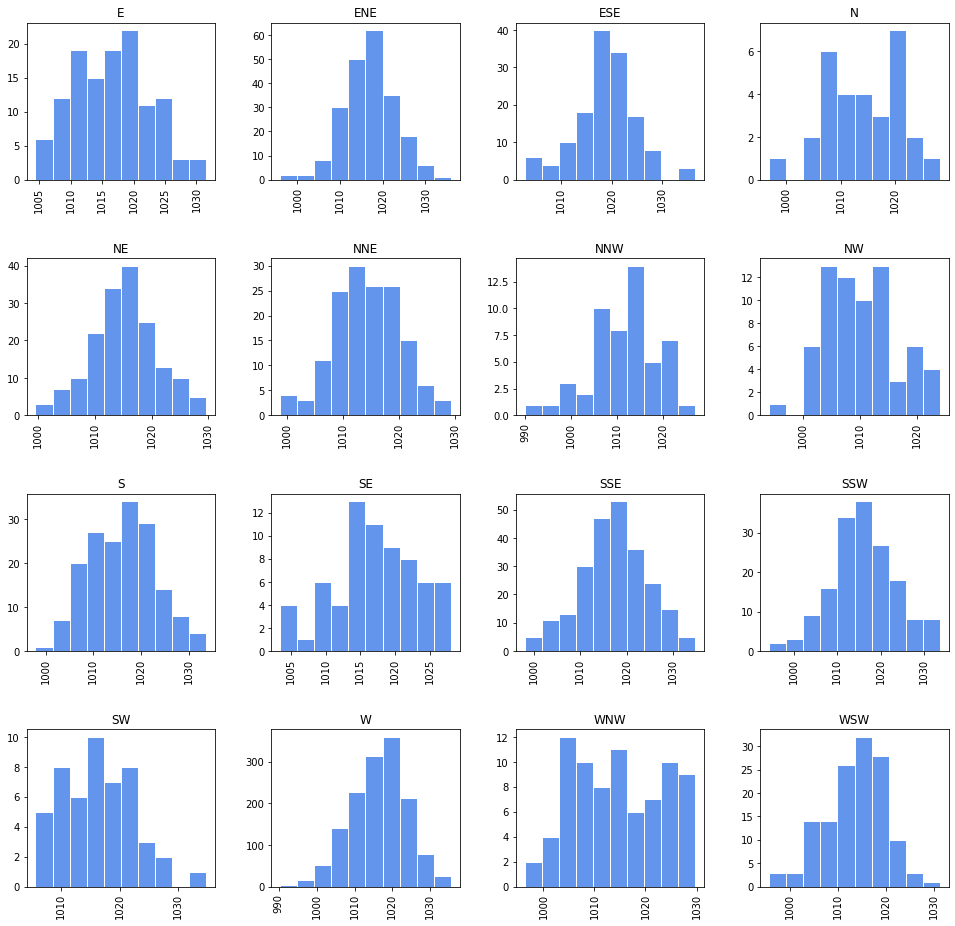

In [12]:
# группировка по WindGustDir,
# цвет заливки васильковый,
# цвет границ столбцов белый,
# размер графика 16 на 16 дюймов 

weather.hist("Pressure3pm", by = "WindGustDir", 
             color = "cornflowerblue", 
             edgecolor = "white", 
             figsize = (16, 16));

Если посмотрим на распределения показателя для направлений ветра SSE (юго-юго-восточный) и NE (северо-восточный), заметим, что они вполне похожи на нормальные. Если хочется формального подтверждения, можно воспользоваться функцией `shapiro()` из модуля `stats` для реализации критерия Шапиро-Уилка для проверки нормальности:

In [13]:
sse = weather[weather["WindGustDir"] == "SSE"]
ne = weather[weather["WindGustDir"] == "NE"]

# H0: выборка взята из нормального распределения
# в данном случае H0 не отвергается в обеих группах
print(stats.shapiro(sse["Pressure3pm"]))
print(stats.shapiro(ne["Pressure3pm"]))

ShapiroResult(statistic=0.9929314255714417, pvalue=0.31388986110687256)
ShapiroResult(statistic=0.9919347167015076, pvalue=0.4645299017429352)


b. Проверим гипотезу о равенстве дисперсий с помощью критерия Левена:

In [14]:
# H0: дисперсии равны
# H1: дисперсии не равны

print(stats.levene(sse["Pressure3pm"], ne["Pressure3pm"]))

LeveneResult(statistic=5.983004249238892, pvalue=0.014867957820738348)


P-value = 0.015, на уровне значимости 5% гипотезу о равенстве дисперсий отвергаем, дисперсии атмосферного давления в двух группах не равны. Значит, для сравнения средних нам нужен двухвыборочный критерий Стьюдента для независимых выборок с предположением о том, что дисперсии генеральных совокупностей, откуда взяты выборки, не равны:

In [17]:
# H0: a1 = a2
# H1: a1 != a2 (по умолчанию двусторонняя)
# equal_var = False (по умолчанию True, меняем)

print(stats.ttest_ind(sse["Pressure3pm"], 
                      ne["Pressure3pm"], 
                      equal_var = False))

Ttest_indResult(statistic=3.302779967685229, pvalue=0.0010421356757018218)


Итак, $t_{набл} = 3.30$, p-value = 0.001, нулевая гипотеза о равенстве средних отвергается на 5%-ном уровне значимости. Средний уровень атмосферного давления в 3 часа дня отличается в дни, когда направление ветра SSE (юго-юго-восточный ветер) и NE (северо-восточный ветер).

*Примечание.* В более новой версии версии `stats` функция возвращает еще и число степеней свободы `df`. Если предполагается, что дисперсии равны, число степеней свободы – такое, какое мы получали в варианте критерия при расчетах вручную, то есть $n_1 + n_2 - 2$. Если предполагается, что дисперсии не равны, то число степеней свободы считается по сложной формуле (см. [здесь](https://ru.wikipedia.org/wiki/T-%D0%BA%D1%80%D0%B8%D1%82%D0%B5%D1%80%D0%B8%D0%B9_%D0%A3%D1%8D%D0%BB%D1%87%D0%B0), этот вариант критерия еще называется тестом Уэлча).

### Задача 3: сравнение распределений

Если мы решаем задачу классификации изображений, обычно нам требуются более продвинутые методы анализа данных, например, логистическая регрессия. Однако на этапе предварительного анализа данных не мешает сравнить средние/распределения характеристик, которые мы планируем использовать в качестве независимых переменных в регрессионной модели для предсказания класса, потому что если они несильно отличаются, модель вряд ли будет осмысленной.

В файле `flowers_two.csv` (источник – [Kaggle](https://www.kaggle.com/datasets/yousefmohamed20/oxford-102-flower-dataset)) хранятся характеристики 186 фотографий, на которых изображены цветы:

* `R`: средняя интенсивность красного цвета (усредненное значение по всем пикселям);
* `G`: средняя интенсивность зеленого цвета;
* `B`: средняя интенсивность синего цвета;
* `Name`: название цветка (`foxglove` – наперстянка, `monkshood` – аконит).

**Мотивация выбора классов**

*Официальная версия.* С одной стороны, растения схожи по форме, с другой стороны, они чаще всего разного цвета, поэтому информации о распределении интенсивности базовых цветов должно хватить для вполне качественной классификации.

*Неофициальная версия.* Названия этих растений – см. ниже :)

<img src="https://github.com/allatambov/PyDat25/blob/main/fun-fan.png?raw=true"></img>

Проверьте на 5% уровне значимости, можно ли считать равными распределения средней интенсивности красного цвета на изображениях с наперстянкой (`foxglove`) и аконитом (`monkshood`).

In [18]:
link = "https://raw.githubusercontent.com/allatambov/StatCS26/refs/heads/main/flowers_two.csv"
data = pd.read_csv(link)
data.head()

,Unnamed: 0,R,G,B,Name
0,0,104.548590,99.650602,91.985842,monkshood
1,1,139.838266,115.665646,137.757932,foxglove
2,2,143.523616,141.907531,116.187864,monkshood
3,3,152.282690,58.711997,86.979517,foxglove
4,4,131.409302,132.706507,121.153530,foxglove


In [21]:
# фильтруем
foxglove = data[data["Name"] == "foxglove"]
aconite = data[data["Name"] == "monkshood"]

# H0: распределения равны, F(x) = G(y)
# H1: распределения не равны, F(x) != G(y)

print(stats.mannwhitneyu(foxglove["R"], aconite["R"]))

MannwhitneyuResult(statistic=3600.0, pvalue=0.2309360753475478)


Нулевая гипотеза не отвергается, p-value = 0.23, значит, распределение интенсивности красного не отличается в двух группах изображений. 

P.S. А вот если сравнить распределения интенсивности синего, разница будет. В целом, если цветы обычно разных цветов, базовой информации об основных цветах в RGB достаточно для получения классификатора вменяемого качества (по крайней мере, если групп две или три, немного).